# 1 — Hidden Markov models and mixed-state presentations

**Exercises · draft for the Iliad Intensive**

A small hidden generator can create a surprisingly complicated
prediction problem. This notebook is a self-contained introduction:
it begins with the probabilistic definition of a hidden Markov model
(HMM), develops the matrix notation from that definition, and ends
with the geometry of its **mixed states**. You will derive the main
results rather than implement an HMM library.

By the end, you should be able to:

- read an edge-emitting HMM diagram and its symbol-labelled matrices;
- calculate word probabilities by multiplying matrices;
- derive posterior beliefs and their recursive Bayesian update;
- turn a belief into probabilities for any future word;
- explain the mixed-state presentation (MSP) as dynamics in a
  probability simplex;
- exhibit two beliefs that agree about the next token but disagree
  about the longer future.

**Route through the notebook:** four numbered **CORE** problems plus
the Mess3 **CORE SYNTHESIS** form the required path. Their timed
exercises total 58 minutes, leaving about 12 minutes in a 70-minute
notebook block for the self-contained primer, supplied visuals, and
transitions. **OPTIONAL CONSOLIDATION** and the **DESIGN STUDIO** are
time buffers: skip them without breaking the argument.

**Working mode.** Most answers are mathematics. Code cells marked
**visual/check** are supplied plumbing: run them, inspect the result,
and return to the derivation. No Python knowledge is assumed.


> <span lang="la">*longum iter est per praecepta, breve et efficax per exempla. multum interest utrum non velit an nesciat. velle non discitur.*</span>
>
> — **Seneca the Younger**, adapted from *Moral Letters to Lucilius* 6.5, 90.46, and 81.13


## Hidden Markov models: what is hidden, given, and inferred

A **hidden Markov model** has a hidden state $S_t$ and an observed
symbol $X_t$. The state is Markovian: once $S_t$ is known, the
distribution of the next step does not depend on earlier history.
We use the **edge-emitting** convention, in which one transition
both emits the next symbol and changes the hidden state:

$$
\Pr(X_{t+1}=x,S_{t+1}=S_j\mid S_t=S_i).
$$

Here is the division of labour.

| Role | Objects |
|---|---|
| **Specified by the model** | hidden states, observation alphabet, and all transition/emission probabilities |
| **Observed by us** | a word $w=x_1\cdots x_L$ of visible symbols |
| **Calculated by us** | $\Pr(w)$, the posterior distribution of the current hidden state, and probabilities of future words |

An initial state distribution must also be specified. In this
notebook we calculate the stationary distribution $\pi$ and use it
as the initial prior. The hidden state itself is never assumed to be
observed.

### The running process: Zero–One–Random (Z1R)

The diagram below is the complete probabilistic specification of
our first HMM. Its visible alphabet is
$\mathcal A=\{\text{'0'},\text{'1'}\}$. A label
$\text{'0'}:p$ means “emit the token '0' while traversing this edge,
with probability $p$.” The code that draws the diagram is supplied
and collapsed by default; the diagram, not the plotting code, is the
mathematical object to read.


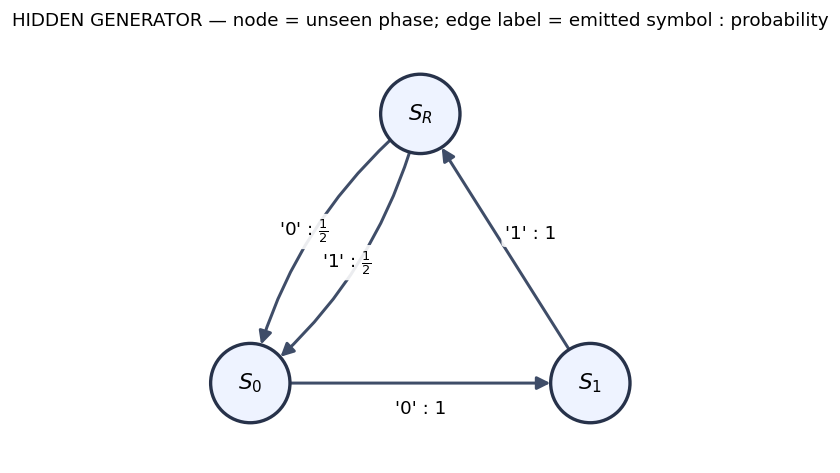

In [1]:
# VISUAL / CHECK — run this cell; there is nothing to edit.
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)

def draw_z1r():
    pos = {
        r"$S_0$": np.array([0.0, 0.0]),
        r"$S_1$": np.array([2.4, 0.0]),
        r"$S_R$": np.array([1.2, 1.9]),
    }
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for name, xy in pos.items():
        ax.add_patch(Circle(xy, 0.28, facecolor="#eef3ff",
                            edgecolor="#27324a", lw=2, zorder=3))
        ax.text(*xy, name, ha="center", va="center", fontsize=13,
                zorder=4)

    def arrow(a, b, label, rad=0.0, offset=(0, 0)):
        patch = FancyArrowPatch(
            pos[a], pos[b], arrowstyle="-|>", mutation_scale=16,
            shrinkA=24, shrinkB=24, lw=1.8, color="#3f4d68",
            connectionstyle=f"arc3,rad={rad}",
        )
        ax.add_patch(patch)
        mid = (pos[a] + pos[b]) / 2 + np.array(offset)
        ax.text(*mid, label, ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=.2", fc="white",
                          ec="none", alpha=.9))

    arrow(r"$S_0$", r"$S_1$", "'0' : 1", offset=(0, -.18))
    arrow(r"$S_1$", r"$S_R$", "'1' : 1", offset=(.18, .10))
    arrow(r"$S_R$", r"$S_0$", r"'0' : $\frac{1}{2}$", rad=.17,
          offset=(-.22, .12))
    arrow(r"$S_R$", r"$S_0$", r"'1' : $\frac{1}{2}$", rad=-.17,
          offset=(.08, -.10))
    ax.set(xlim=(-.6, 3.0), ylim=(-.55, 2.45), aspect="equal")
    ax.axis("off")
    ax.set_title(
        "HIDDEN GENERATOR — node = unseen phase; "
        "edge label = emitted symbol : probability",
        fontsize=11,
    )
    plt.show()

draw_z1r()


### From the diagram to matrices

Z1R repeatedly emits '0', then '1', then a fair random bit, and
repeats. At time $t$, $S_t$ is the hidden phase **before** the next
edge. Traversing that edge emits $X_{t+1}$ and arrives at
$S_{t+1}$:

- $S_0$: emit '0', then arrive at $S_1$;
- $S_1$: emit '1', then arrive at $S_R$;
- $S_R$: emit a fair random token, then arrive at $S_0$.

We now **vectorize** the probabilities in the diagram. For each
possible visible symbol $x$, define one symbol-labelled matrix

$$
T^{(x)}_{ij}
=\Pr(X_{t+1}=x,S_{t+1}=S_j\mid S_t=S_i).
$$

Rows mean the phase **before** an edge and columns mean the phase
**after** it. Thus $T^{(\text{'0'})}$ contains only edges that emit
'0', and $T^{(\text{'1'})}$ contains only edges that emit '1'.

A symbol matrix is not generally row-stochastic: it contains only
the joint events that emit one symbol. After forgetting which symbol
was emitted, we obtain the ordinary hidden-state transition matrix

$$
P=\sum_{x\in\mathcal A}T^{(x)}.
$$

It is $P$, not each $T^{(x)}$, whose rows sum to one. We use row
vectors for state distributions, so one hidden-state step is
$\mu_{t+1}=\mu_tP$.


## CORE 1/4 — Reconstruct the generator (10 minutes)

1. Without looking at code, reconstruct the complete $3\times3$
   matrices $T^{(\text{'0'})}$ and $T^{(\text{'1'})}$ from the
   diagram.
2. In terms of the matrices $T^{(x)}$, write the identity expressing
   that the probabilities of all possible emitted-symbol/destination
   pairs sum to one from each source state. Explain why this does
   **not** require either symbol matrix to have row sums equal to
   one.

   $$
   \sum_{x\in\mathcal A}\sum_j T^{(x)}_{ij}=1
   \quad\text{for each source state }i.
   $$

3. Consider the hidden-state transition matrix
   $P=T^{(\text{'0'})}+T^{(\text{'1'})}$. Explain what information
   is discarded by this sum, then verify that the uniform row
   vector $\pi=(1/3,1/3,1/3)$ is stationary: $\pi P=\pi$.
4. Use the diagram or your matrices to calculate
   $\Pr(X_1=\text{'0'})$ under $\pi$, keeping the two hidden-source
   contributions visible.

<details><summary>Hint 1</summary>
Each arrow contributes to exactly one entry of exactly one symbol
matrix.
</details>

<details><summary>Hint 2</summary>
Stationarity is a statement about the state-transition matrix
$P$, after marginalizing (forgetting) which symbol was emitted.
</details>


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


In [2]:
# POST-ANSWER CHECK / SETUP — matrices are revealed only after CORE 1.
T0 = np.array([
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.5, 0.0, 0.0],
])
T1 = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.5, 0.0, 0.0],
])
T = np.stack([T0, T1])
P_hidden = T0 + T1
eta_empty = np.ones(3) / 3

print("T^('0') =\n", T0)
print("T^('1') =\n", T1)
print("P = T^('0') + T^('1') =\n", P_hidden)
print("row sums after adding symbols:", T.sum(axis=(0, 2)))


T^('0') =
 [[0.  1.  0. ]
 [0.  0.  0. ]
 [0.5 0.  0. ]]
T^('1') =
 [[0.  0.  0. ]
 [0.  0.  1. ]
 [0.5 0.  0. ]]
P = T^('0') + T^('1') =
 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
row sums after adding symbols: [1. 1. 1.]


### Notation card — keep this visible

| Symbol | Meaning | Shape |
|---|---|---|
| $T^{(x)}$ | model-given joint transition/emission matrix for token $x$ | $3\times3$ |
| $P=\sum_xT^{(x)}$ | hidden-state transition after the token is forgotten | $3\times3$ |
| $\pi=\eta^{(\epsilon)}$ | stationary initial belief, calculated from $\pi P=\pi$ | $1\times3$ row |
| $\mathbf 1=(1,1,1)^\top$ | sums over the unknown final hidden state | $3\times1$ column |
| $T^{(w)}=T^{(x_1)}\cdots T^{(x_L)}$ | all hidden paths that emit $w=x_1\cdots x_L$ | $3\times3$ |
| $\alpha^{(w)}_j=\Pr(w,S_L=S_j)$ | unnormalized forward row | $1\times3$ |
| $\eta^{(w)}_j=\Pr(S_L=S_j\mid w)$ | normalized posterior belief | $1\times3$ |

The superscript $(w)$ labels an observed word; it is not a matrix
power. From here on, $\epsilon$ denotes the empty history.


## CORE 2/4 — From hidden paths to word probabilities (12 minutes)

Let $w=x_1x_2\ldots x_L$ be an observed word and write
$T^{(w)}=T^{(x_1)}T^{(x_2)}\cdots T^{(x_L)}$.

1. For a two-symbol word $x_1x_2$, begin with a sum over the unknown
   hidden states $s_0,s_1,s_2$. Regroup the factors until you can
   recognize matrix multiplication.
2. Generalize the calculation to a word
   $w=x_1\ldots x_L$ and show that the forward row obeys

   $$
   \alpha^{(wx)}=\alpha^{(w)}T^{(x)},\qquad
   \Pr(w)=\alpha^{(w)}\mathbf 1
   =\pi T^{(w)}\mathbf 1.
   $$

3. Use either hidden paths or the matrix formula to calculate
   $\Pr(\text{'010'})$ for Z1R. Use the stationary prior $\pi$, or
   choose another prior and state it explicitly.
4. Explain what information $\alpha^{(w)}$ retains that the scalar
   $\Pr(w)$ discards.

<details><summary>Hint 1</summary>
For fixed $s_0,s_1,s_2$, the path contribution is
$\eta_{s_0}T^{(x_1)}_{s_0s_1}T^{(x_2)}_{s_1s_2}$.
</details>

<details><summary>Hint 2</summary>
The final multiplication by $\mathbf 1$ sums over the unknown final
hidden state.
</details>


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


In [3]:
# CHECK — compare the matrix calculation with your arithmetic.
def forward(word, initial=eta_empty, transition_tensor=T):
    vector = np.asarray(initial, dtype=float)
    for symbol in word:
        vector = vector @ transition_tensor[int(symbol)]
    return vector

def word_probability(word, initial=eta_empty, transition_tensor=T):
    return float(forward(word, initial, transition_tensor).sum())

for word in ["0", "1", "00", "01", "10", "11"]:
    print(f"Pr('{word}') = {word_probability(word):.6f}")


Pr('0') = 0.500000
Pr('1') = 0.500000
Pr('00') = 0.166667
Pr('01') = 0.333333
Pr('10') = 0.333333
Pr('11') = 0.166667


## CORE 3/4 — Bayes as a recursive geometric map (16 minutes)

After observing $w$, define the **belief state**

$$
\eta^{(w)}_j=\Pr(S_{\lvert w\rvert}=S_j\mid X_{1:\lvert w\rvert}=w).
$$

In computational mechanics this posterior distribution over hidden
generator states is called a **mixed state**. “Mixed” means that the
observer may assign probability to several hidden states; a belief
concentrated on one state is a **pure state**.

The **mixed-state presentation (MSP)** keeps every reachable mixed
state and its weighted Bayesian edges. From belief $\eta$, token $x$
has probability

$$
p_x(\eta)=\eta T^{(x)}\mathbf 1.
$$

Write $F_x(\eta)$ for the updated belief after observing $x$.
When $p_x(\eta)>0$, the MSP contains the edge
$\eta\xrightarrow{x:p_x(\eta)}F_x(\eta)$. If $p_x(\eta)=0$, that
observation is impossible from $\eta$, so there is no such edge and
the normalized update $F_x(\eta)$ is undefined rather than $0/0$.

1. Use $\alpha^{(w)}$ to derive

   $$
   \eta^{(w)}
   =\frac{\alpha^{(w)}}{\alpha^{(w)}\mathbf1}
   =\frac{\pi T^{(w)}}{\pi T^{(w)}\mathbf1}.
   $$

2. Now suppose the current belief is an arbitrary row $\eta$ and
   the next observed symbol is $x$. Derive the recursive map

   $$
   F_x(\eta)=\frac{\eta T^{(x)}}
   {\eta T^{(x)}\mathbf1},
   $$

   and interpret its denominator probabilistically.
3. Calculate $\eta^{(\text{'0'})}$, $\eta^{(\text{'01'})}$, and
   $\eta^{(\text{'10'})}$ by
   composing these maps. Check explicitly that the order matters:
   $F_{\text{'1'}}(F_{\text{'0'}}(\pi))\ne
   F_{\text{'0'}}(F_{\text{'1'}}(\pi))$. For
   $\eta^{(\text{'01'})}$, report all three coordinates explicitly
   as $\Pr(S_2=s\mid\text{'01'})$.
4. Where do all three-component beliefs live geometrically? Why is
   $F_x$ generally rational rather than linear, even though its
   numerator is linear?

<details><summary>Hint 1</summary>
Bayes' rule divides the joint row
$(\Pr(w,S_L=S_j))_j$ by its total mass.
</details>

<details><summary>Hint 2</summary>
Treat the current posterior as the next step's prior. Compare
histories '01' and '10', rather than recomputing '01' twice.
</details>


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


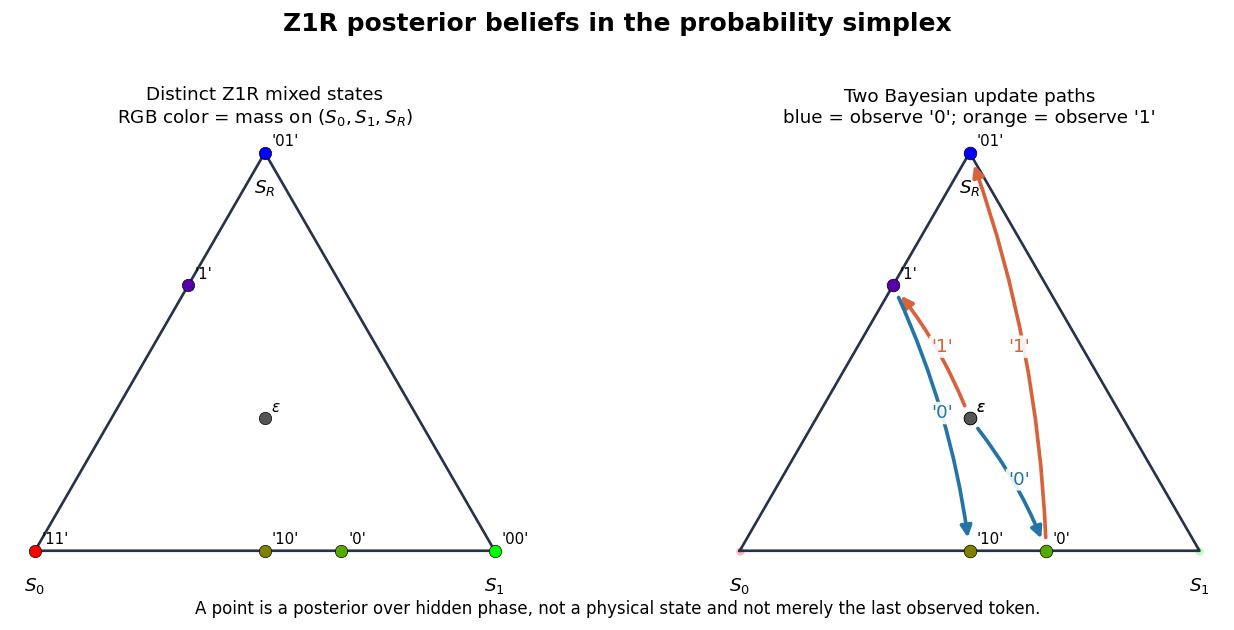

31 reachable histories collapse to 7 distinct belief states.


In [4]:
# VISUAL / CHECK — reachable Z1R beliefs in the hidden-state simplex.
simplex_vertices = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, np.sqrt(3) / 2],
])

def belief(word, initial=eta_empty, transition_tensor=T):
    unnormalized = forward(word, initial, transition_tensor)
    mass = unnormalized.sum()
    if mass <= 1e-14:
        raise ValueError(f"Impossible history: {word}")
    return unnormalized / mass

def reachable_beliefs(alphabet, max_depth, initial, tensor):
    result = {"": np.asarray(initial, dtype=float)}
    for depth in range(1, max_depth + 1):
        for symbols in itertools.product(alphabet, repeat=depth):
            word = "".join(map(str, symbols))
            if word_probability(word, initial, tensor) > 1e-14:
                result[word] = belief(word, initial, tensor)
    return result

z1r_beliefs = reachable_beliefs([0, 1], 5, eta_empty, T)
belief_groups = {}
for word, b in z1r_beliefs.items():
    key = tuple(np.round(b, 10))
    belief_groups.setdefault(key, {"belief": b, "histories": []})
    belief_groups[key]["histories"].append(word)

# Regression checks for the weighted-edge definition of the MSP.
assert np.isclose(np.array([1.0, 0.0, 0.0]) @ T1 @ np.ones(3), 0)
for group in belief_groups.values():
    b = group["belief"]
    edge_probabilities = np.array([
        b @ symbol_matrix @ np.ones(3)
        for symbol_matrix in (T0, T1)
    ])
    assert np.isclose(edge_probabilities.sum(), 1)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.2))
triangle = np.vstack([simplex_vertices, simplex_vertices[0]])
for ax in axes:
    ax.plot(triangle[:, 0], triangle[:, 1],
            color="#27324a", lw=1.6)
    for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_R$"],
                         simplex_vertices):
        ax.text(*(xy + np.array([0.0, -.055])), label,
                ha="center", va="top", fontsize=11)
    ax.set_aspect("equal")
    ax.axis("off")

# Left: the state set, uncluttered.
for group in belief_groups.values():
    b = group["belief"]
    xy = b @ simplex_vertices
    representative = min(
        group["histories"], key=lambda word: (len(word), word)
    )
    label = (
        r"$\epsilon$" if representative == ""
        else f"'{representative}'"
    )
    axes[0].scatter(*xy, s=55, color=b, edgecolor="black",
                    linewidth=.4, zorder=3)
    axes[0].annotate(label, xy, xytext=(4, 4),
                     textcoords="offset points", fontsize=9)
axes[0].set_title(
    "Distinct Z1R mixed states\n"
    "RGB color = mass on $(S_0,S_1,S_R)$",
    fontsize=11,
)

# Right: only two update paths, so the arrows remain legible.
for group in belief_groups.values():
    b = group["belief"]
    axes[1].scatter(*(b @ simplex_vertices), s=25, color=b,
                    alpha=.28, linewidth=0, zorder=1)

symbol_colors = {"0": "#2474a6", "1": "#d6633c"}
for path in [["", "0", "01"], ["", "1", "10"]]:
    for source_word, target_word in zip(path[:-1], path[1:]):
        start = belief(source_word) @ simplex_vertices
        destination = belief(target_word) @ simplex_vertices
        symbol = target_word[-1]
        axes[1].add_patch(FancyArrowPatch(
            start, destination, arrowstyle="-|>",
            mutation_scale=14, shrinkA=8, shrinkB=8, lw=2.2,
            color=symbol_colors[symbol],
            connectionstyle=f"arc3,rad={-.08 if symbol == '0' else .08}",
            zorder=3,
        ))
        midpoint = (start + destination) / 2
        axes[1].text(*midpoint, f"'{symbol}'", fontsize=11,
                     color=symbol_colors[symbol],
                     bbox=dict(boxstyle="round,pad=.12",
                               fc="white", ec="none", alpha=.9))
    for word in path:
        xy = belief(word) @ simplex_vertices
        axes[1].scatter(*xy, s=58, color=belief(word),
                        edgecolor="black", linewidth=.4, zorder=4)
        axes[1].annotate(
        r"$\epsilon$" if word == "" else f"'{word}'",
            xy, xytext=(4, 4), textcoords="offset points",
            fontsize=9,
        )
axes[1].set_title(
    "Two Bayesian update paths\n"
    "blue = observe '0'; orange = observe '1'",
    fontsize=11,
)
fig.suptitle(
    "Z1R posterior beliefs in the probability simplex",
    fontsize=15, fontweight="bold",
)
fig.text(
    .5, .015,
    "A point is a posterior over hidden phase, not a physical state "
    "and not merely the last observed token.",
    ha="center", fontsize=10,
)
plt.tight_layout(rect=(0, .05, 1, .92))
plt.show()

print(f"{len(z1r_beliefs)} reachable histories collapse to "
      f"{len(belief_groups)} distinct belief states.")


The original HMM describes how the hidden world generates data. Its
**mixed-state presentation** describes the corresponding inference
process: the states are reachable posterior beliefs, while each
possible token supplies both an edge probability $p_x(\eta)$ and a
destination $F_x(\eta)$.

The plot labels states by histories for convenience, but the state
itself is the posterior vector. Two histories that yield the same
posterior land at the same point. Z1R's nearly deterministic cycle
makes histories merge onto only seven beliefs; a finite-state HMM
can nevertheless have infinitely many reachable mixed states.


## CORE 4/4 — Same next token, different future (12 minutes)

From a belief $\eta$, the probability of a future word
$u=u_1\ldots u_k$ is

$$
\Pr(u\mid\eta)=\eta T^{(u)}\mathbf 1.
$$

1. Derive the next-token map
   $\Pr(X_{\mathrm{next}}=x\mid\eta)=\eta T^{(x)}\mathbf 1$.
   Then, for a history $h$ and a whole new future word $u$, show
   that, when $\Pr(u\mid h)>0$, the destination-state row before
   normalization is

   $$
   \eta^{(h)}T^{(u)}
   =\Pr(u\mid h)\eta^{(hu)}.
   $$

   Summing this row should recover
   $\Pr(u\mid h)=\eta^{(h)}T^{(u)}\mathbf1$.
2. Using the beliefs $\eta^{(\text{'01'})}$ and
   $\eta^{(\text{'10'})}$ from CORE 3, show that both give the
   next-token distribution $(1/2,1/2)$.
3. For each belief, calculate the distribution over
   '00', '01', '10', and '11'. As a separate three-step check,
   calculate the probability that the **next three symbols** are
   '010' after the history '01'.
4. Imagine compressing every history $h$ to only its next-token
   vector

   $$
   q(h)=\big(\Pr(\text{'0'}\mid h),
   \Pr(\text{'1'}\mid h)\big),
   $$

   and then updating recursively by one fixed rule
   $q(hx)=G(q(h),x)$. The histories '01' and '10' have the same
   $q$. Show that after both histories next emit '1', their
   following-token predictions differ. Why is that impossible for
   such a rule $G$?
5. State the limited conclusion carefully. Why does this rule out
   next-token probabilities as a sufficient recurrent state, but
   **not** prove that a full-context model literally stores the HMM
   posterior $\eta$?

<details><summary>Hint 1</summary>
You already found $\eta^{(\text{'01'})}$. For '10', propagate one token at a
time and normalize.
</details>

<details><summary>Hint 2</summary>
Under $\eta^{(\text{'01'})}$ the hidden state is certainly $S_R$;
under $\eta^{(\text{'10'})}$ it is an equal mixture of $S_0$ and
$S_1$.
</details>


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


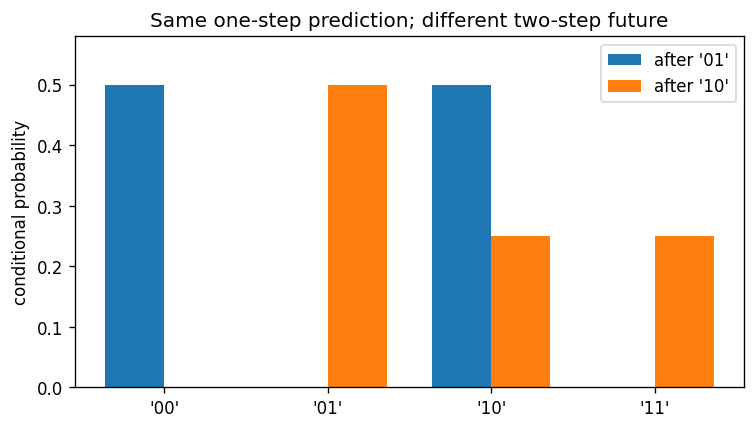

belief after '01': [0. 0. 1.]
belief after '10': [0.5 0.5 0. ]
next-token distributions: [0.5 0.5] [0.5 0.5]


In [5]:
# VISUAL / CHECK — compare the two future distributions.
eta_01 = belief("01")
eta_10 = belief("10")
future_words = ["00", "01", "10", "11"]

def future_distribution(current_belief, words, tensor=T):
    return np.array([
        word_probability(w, current_belief, tensor) for w in words
    ])

next_01 = future_distribution(eta_01, ["0", "1"])
next_10 = future_distribution(eta_10, ["0", "1"])
two_01 = future_distribution(eta_01, future_words)
two_10 = future_distribution(eta_10, future_words)

assert np.allclose(next_01, next_10)
assert not np.allclose(two_01, two_10)

print("belief after '01':", eta_01)
print("belief after '10':", eta_10)
print("next-token distributions:", next_01, next_10)

x = np.arange(len(future_words))
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(x - .18, two_01, .36, label="after '01'")
ax.bar(x + .18, two_10, .36, label="after '10'")
ax.set(xticks=x, xticklabels=[f"'{w}'" for w in future_words],
       ylim=(0, .58),
       ylabel="conditional probability",
       title="Same one-step prediction; different two-step future")
ax.legend()
plt.show()


**Model-relative caveat.** A belief over the chosen HMM's hidden
states is sufficient for prediction relative to that realization,
but it need not be the minimal observable predictive state.
Distinct beliefs can, in principle, assign the same probability to
**every** future word;
an observable predictive representation would merge such beliefs.
Later notebooks return to that distinction.


## CORE SYNTHESIS — Build the Mess3 recursion (8 minutes)

Z1R has only seven reachable mixed states. That finiteness is a
special property of Z1R, not a consequence of having three hidden
states. We now apply exactly the same inference machinery to Mess3,
another three-state HMM whose mixed states have a far richer
geometry. There is no new formalism in this section.

Mess3 has the visible alphabet
$\{\text{'0'},\text{'1'},\text{'2'}\}$. Assume we are given its
three symbol-labelled matrices and a uniform initial belief:

$$
T^{(\text{'0'})}=
\begin{pmatrix}
.14&.06&.06\\ .03&.28&.06\\ .03&.06&.28
\end{pmatrix},\qquad
T^{(\text{'1'})}=
\begin{pmatrix}
.28&.03&.06\\ .06&.14&.06\\ .06&.03&.28
\end{pmatrix},
$$

$$
T^{(\text{'2'})}=
\begin{pmatrix}
.28&.06&.03\\ .06&.28&.03\\ .06&.06&.14
\end{pmatrix},\qquad
\eta^{(\epsilon)}=(1/3,1/3,1/3).
$$

A point $(\eta_0,\eta_1,\eta_2)$ in the belief triangle means that
the observer assigns probability $\eta_i$ to hidden state $S_i$.
Its three corners are the **certainty beliefs** $(1,0,0)$,
$(0,1,0)$, and $(0,0,1)$. For a fixed observed token $x$, update
each corner with

$$
F_x(\eta)=\frac{\eta T^{(x)}}{\eta T^{(x)}\mathbf1}.
$$

At a certainty belief this simply normalizes one row of $T^{(x)}$.
For a certainty belief $e_i$, write
$r_i=e_iT^{(x)}\mathbf1$ for the probability of token $x$ and
$v_i=F_x(e_i)$ for the updated corner. For an uncertain belief
$\eta$,

$$
F_x(\eta)=\sum_i\beta_i v_i,
\qquad
\beta_i=\frac{\eta_i r_i}{\sum_k \eta_k r_k}.
$$

Thus the update uses **likelihood-reweighted** coefficients, not
generally the original coordinates $\eta_i$. All Mess3 row masses
are positive, so the possible coefficients $\beta$ fill the simplex
and the three corner images bound exactly the region of posteriors
after observing $x$. The first visual shows those three regions; it
does not reveal any length-two calculations.


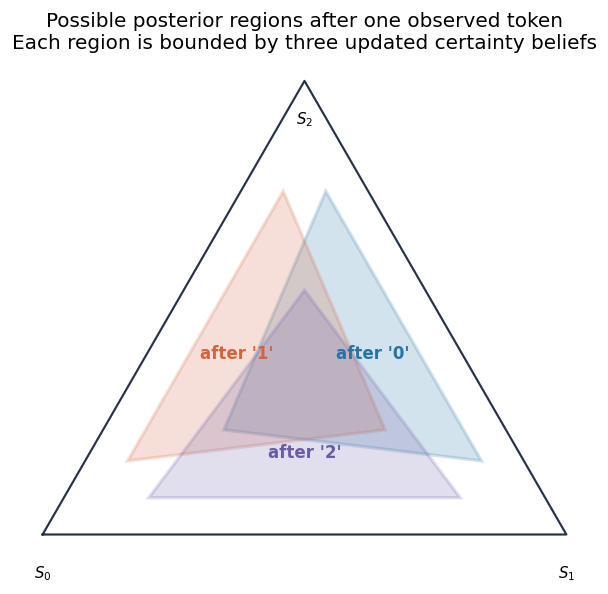

In [6]:
# CORE VISUAL 1 — one-symbol image triangles only. Run; do not edit.
from matplotlib.patches import Polygon

mess3_T = np.array([
    [[.14,.06,.06], [.03,.28,.06], [.03,.06,.28]],
    [[.28,.03,.06], [.06,.14,.06], [.06,.03,.28]],
    [[.28,.06,.03], [.06,.28,.03], [.06,.06,.14]],
], dtype=float)
mess3_initial = np.ones(3) / 3
map_colors = ["#2474a6", "#d6633c", "#6b5aa6"]
label_offsets = [np.array([.055, .015]),
                 np.array([-.055, .015]),
                 np.array([0.0, -.045])]

# Regression check: Bayesian image weights are likelihood-reweighted.
rows = mess3_T[0]
row_masses = rows.sum(axis=1)
corner_images = rows / row_masses[:, None]
beta = mess3_initial * row_masses / (mess3_initial @ row_masses)
direct_update = (
    mess3_initial @ rows / (mess3_initial @ rows).sum()
)
assert np.allclose(beta @ corner_images, direct_update)
assert not np.allclose(mess3_initial @ corner_images, direct_update)

fig, ax = plt.subplots(figsize=(6.7, 5.4))
ax.plot(triangle[:, 0], triangle[:, 1], color="#27324a", lw=1.3)
for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_2$"],
                     simplex_vertices):
    ax.text(*(xy + np.array([0.0, -.055])), label,
            ha="center", va="top", fontsize=9)

for symbol in range(3):
    mapped_beliefs = mess3_T[symbol] / (
        mess3_T[symbol].sum(axis=1, keepdims=True)
    )
    mapped_vertices = mapped_beliefs @ simplex_vertices
    ax.add_patch(Polygon(
        mapped_vertices, closed=True,
        facecolor=map_colors[symbol], edgecolor=map_colors[symbol],
        alpha=.20, lw=2,
    ))
    center = mapped_vertices.mean(axis=0) + label_offsets[symbol]
    ax.text(
        *center, f"after '{symbol}'",
        ha="center", va="center", fontsize=10,
        color=map_colors[symbol], fontweight="bold",
    )

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "Possible posterior regions after one observed token\n"
    "Each region is bounded by three updated certainty beliefs",
    fontsize=12,
)
plt.show()


Now do one composition before the reveal.

1. Normalize the three rows of $T^{(\text{'0'})}$. These are the
   updated beliefs obtained by observing '0' when starting with
   certainty in $S_0$, $S_1$, or $S_2$. Match them to the corners
   of the blue region.
2. Starting from the uniform belief, calculate
   $\eta^{(\text{'0'})}$ and then
   $\eta^{(\text{'01'})}=F_{\text{'1'}}
   (\eta^{(\text{'0'})})$.
3. On the one-token visual, identify the region that must contain
   $\eta^{(\text{'01'})}$. Explain why the **last** observed token,
   rather than the first, determines that outer region.
4. Predict qualitatively what repeated compositions will do.
5. Does having three hidden generator states constrain the observer
   to only three predictive states?

<details><summary>Hint</summary>
For a history '01', apply the '0' update first and the '1' update
second. Every point produced by the second update lies in the region
labelled “after '1'.”
</details>


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


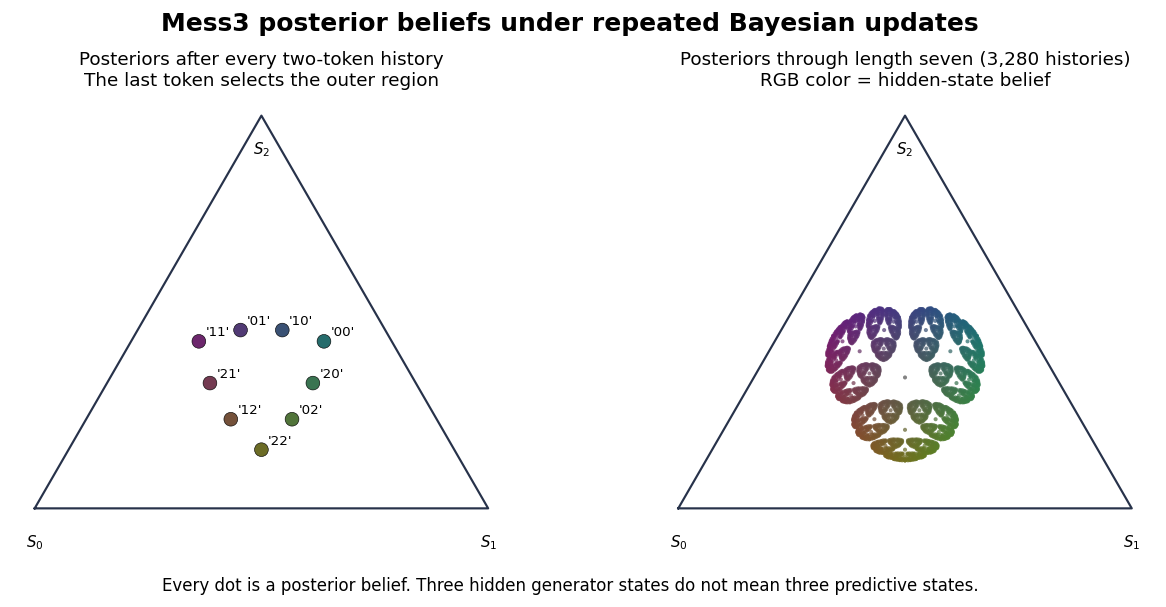

In [7]:
# CORE VISUAL 2 — reveal the recursive layer and the final geometry.
mess3_beliefs = reachable_beliefs(
    [0, 1, 2], 7, mess3_initial, mess3_T
)
B = np.array(list(mess3_beliefs.values()))
XY = B @ simplex_vertices

fig, axes = plt.subplots(1, 2, figsize=(10.8, 5.0))
for ax in axes:
    ax.plot(triangle[:, 0], triangle[:, 1],
            color="#27324a", lw=1.3)
    for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_2$"],
                         simplex_vertices):
        ax.text(*(xy + np.array([0.0, -.055])), label,
                ha="center", va="top", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")

depth2_words = list(itertools.product(range(3), repeat=2))
depth2_B = np.array([
    belief("".join(map(str, word)), mess3_initial, mess3_T)
    for word in depth2_words
])
depth2_XY = depth2_B @ simplex_vertices
axes[0].scatter(
    depth2_XY[:, 0], depth2_XY[:, 1],
    c=np.clip(depth2_B, 0, 1), s=68,
    edgecolor="black", linewidth=.35,
)
for word, xy in zip(depth2_words, depth2_XY):
    axes[0].annotate(
        "'" + "".join(map(str, word)) + "'",
        xy, xytext=(4, 3),
        textcoords="offset points", fontsize=8,
    )
axes[0].set_title(
    "Posteriors after every two-token history\n"
    "The last token selects the outer region",
    fontsize=11,
)

axes[1].scatter(
    XY[:, 0], XY[:, 1], c=np.clip(B, 0, 1),
    s=6, alpha=.72, linewidth=0,
)
axes[1].set_title(
    f"Posteriors through length seven ({len(B):,} histories)\n"
    "RGB color = hidden-state belief",
    fontsize=11,
)
fig.suptitle(
    "Mess3 posterior beliefs under repeated Bayesian updates",
    fontsize=15, fontweight="bold",
)
fig.text(
    .5, .015,
    "Every dot is a posterior belief. Three hidden generator states "
    "do not mean three predictive states.",
    ha="center", fontsize=10,
)
fig.subplots_adjust(
    left=.04, right=.98, bottom=.12, top=.84, wspace=.12
)
plt.show()


## Optional consolidation — the full pipeline (5 minutes)

Complete this chain in words, then identify which arrows are linear,
which require normalization, and which change the interpretation
rather than the underlying calculation:

$$
\text{HMM edges}
\longrightarrow \alpha^{(w)}
\longrightarrow \Pr(w)
\longrightarrow \eta^{(w)}
\longrightarrow F_x
\longrightarrow \text{belief geometry}
\longrightarrow \Pr(u\mid\eta).
$$


#### Your answer

_Work on paper or edit this cell. Show enough intermediate reasoning to
locate a disagreement._


### Exit ticket

In two sentences: why can prediction be geometrically more
complicated than generation, even when the data-generating HMM has
only three hidden states?


## Optional design studio (12–15 minutes) — tune rather than start from nothing

The supplied family has a cyclic '0' skeleton:

$$
S_0\xrightarrow{\text{'0'}:a}S_1,\quad
S_1\xrightarrow{\text{'0'}:b}S_2,\quad
S_2\xrightarrow{\text{'0'}:c}S_0,
$$

with a '1' self-loop carrying the remaining probability at each
state.

Choose one brief and its starting preset:

| Brief | Start from $(a,b,c)$ | Operational target |
|---|---|---|
| **fast synchronization** | $(.95,.55,.08)$ | median posterior entropy below $0.35$ nats by depth 8 |
| **persistent ambiguity** | $(.62,.52,.42)$ | median entropy above $0.70$ nats and no single coordinate above $.95$ |
| **branching geometry** | $(.88,.50,.15)$ | the centroids after final token '0' versus '1' are far apart |

1. Predict which parameters make an observed '0' most diagnostic.
2. Run the matching preset and compare the printed metrics with its
   target.
3. Change **one parameter**, state the direction in which each metric
   should move, and rerun.
4. Report one failed prediction or one tradeoff between the targets.

The metrics are only handles for reasoning, not canonical measures
of geometric complexity.


In [8]:
# OPTIONAL DESIGN CELL — pick a preset, then edit one number.
a, b, c = 0.88, 0.50, 0.15  # branching-geometry preset


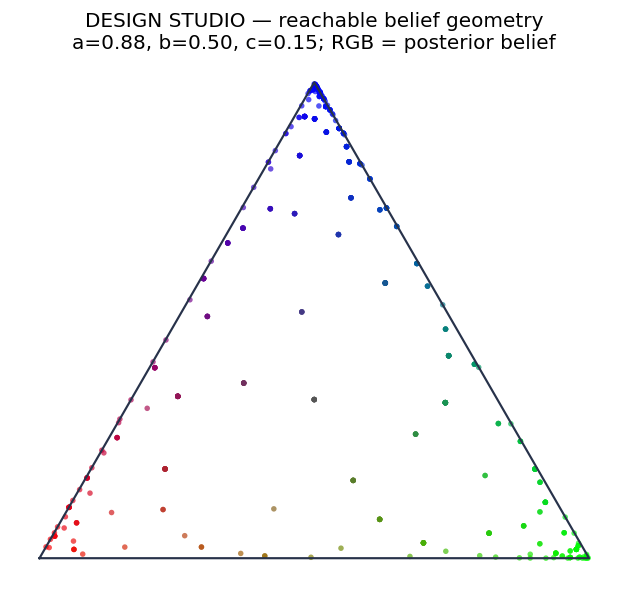

stationary initial belief: [0.1159 0.204  0.6801]
median posterior entropy (nats): 0.5124484948629559
largest posterior coordinate: 0.998175519706804
last-symbol centroid separation: 0.3865838040870767


In [9]:
# PROVIDED VISUALIZER — run after choosing a, b, and c.

def noisy_cycle(a, b, c):
    assert all(0 <= z <= 1 for z in (a, b, c))
    symbol_0 = np.array([
        [0, a, 0],
        [0, 0, b],
        [c, 0, 0],
    ], dtype=float)
    symbol_1 = np.diag([1-a, 1-b, 1-c])
    return np.stack([symbol_0, symbol_1])

custom_T = noisy_cycle(a, b, c)
state_T = custom_T.sum(axis=0)
evals, evecs = np.linalg.eig(state_T.T)
custom_initial = np.real(evecs[:, np.argmin(np.abs(evals - 1))])
custom_initial = custom_initial / custom_initial.sum()

custom_beliefs = reachable_beliefs(
    [0, 1], 8, custom_initial, custom_T
)
C = np.array(list(custom_beliefs.values()))
Cxy = C @ simplex_vertices

fig, ax = plt.subplots(figsize=(6.5, 5.7))
ax.plot(triangle[:, 0], triangle[:, 1], color="#27324a", lw=1.3)
ax.scatter(Cxy[:, 0], Cxy[:, 1], c=np.clip(C, 0, 1), s=11,
           alpha=.68, linewidth=0)
ax.set_title(
    "DESIGN STUDIO — reachable belief geometry\n"
    f"a={a:.2f}, b={b:.2f}, c={c:.2f}; RGB = posterior belief"
)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

safe_C = np.clip(C, 1e-15, 1)
entropies = -(safe_C * np.log(safe_C)).sum(axis=1)
histories_custom = list(custom_beliefs)
last_zero = np.array([
    custom_beliefs[w] for w in histories_custom if w.endswith("0")
])
last_one = np.array([
    custom_beliefs[w] for w in histories_custom if w.endswith("1")
])
centroid_gap = np.linalg.norm(
    last_zero.mean(axis=0) - last_one.mean(axis=0)
)
print("stationary initial belief:", custom_initial)
print("median posterior entropy (nats):", np.median(entropies))
print("largest posterior coordinate:", C.max())
print("last-symbol centroid separation:", centroid_gap)
